In [1]:
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from joblib import Parallel, delayed
import Conor as c


In [2]:
def compute_regret_slopes(results, scalings, v_star, fit_start=500):
    """Fit log-log regret slope for each scaling. Returns DataFrame + regret dict."""
    records, regret_dict = [], {}
    for s in scalings:
        label   = f'scaling={s}'
        vpi     = results[label]['vpi']
        eps     = np.arange(1, len(vpi) + 1)
        cum_reg = np.cumsum(np.maximum(v_star - vpi, 0.0))
        regret_dict[label] = cum_reg
        mask = (eps >= fit_start) & (cum_reg > 0)
        if mask.sum() < 10:
            records.append({'scaling': s, 'alpha': float('nan'), 'r_squared': float('nan')})
            continue
        slope, _, r, _, _ = stats.linregress(np.log(eps[mask]), np.log(cum_reg[mask]))
        records.append({'scaling': s, 'alpha': round(slope, 4), 'r_squared': round(r**2, 4)})
    return pd.DataFrame(records), regret_dict


# Reward 1 — asymmetric quadratic

In [3]:
importlib.reload(c)

cfg_r1 = c.ExpConfig(
    starting_state=4.0,
    action_lo=-5.0,
    action_hi=5.0,
    rho=10.0,
    reward_step_fn=c.reward_quadratic_asymmetric,
)
solver_r1 = c.BellmanSolverScalar(cfg_r1, n_state=201, n_action=201, n_quad=41)
solver_r1.solve()
V_STAR_R1 = solver_r1.get_value(cfg_r1.starting_state)
print(f'V*(x0) = {V_STAR_R1:.4f}  (expected ≈ 0.0)')


V*(x0) = -0.0011  (expected ≈ 0.0)


In [4]:
scalings_r1 = [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100, 500]

configs = [
    c.ExpConfig(
        starting_state=4.0, action_lo=-5.0, action_hi=5.0,
        initial_q=100.0, rho=10.0,
        reward_step_fn=c.reward_quadratic_asymmetric,
        label=f'scaling={s}', scaling=s, alpha=0.5, nEps=2000, n_seeds=10,
    )
    for s in scalings_r1
]
results_sweep_r1 = c.run_experiment(configs, n_jobs=-1)



--- Running: scaling=0.01 ---
    Done. Final mean VPI: -38.065

--- Running: scaling=0.05 ---
    Done. Final mean VPI: -37.888

--- Running: scaling=0.1 ---
    Done. Final mean VPI: -37.179

--- Running: scaling=0.5 ---
    Done. Final mean VPI: -29.719

--- Running: scaling=1 ---
    Done. Final mean VPI: -19.982

--- Running: scaling=5 ---
    Done. Final mean VPI: -3.888

--- Running: scaling=10 ---
    Done. Final mean VPI: -3.755

--- Running: scaling=50 ---
    Done. Final mean VPI: -60.349

--- Running: scaling=100 ---
    Done. Final mean VPI: -100.414

--- Running: scaling=500 ---
    Done. Final mean VPI: -149.898


In [5]:
summary_r1 = []
for s in scalings_r1:
    label = f'scaling={s}'
    vpi  = results_sweep_r1[label]['vpi']
    arms = results_sweep_r1[label]['arms']
    summary_r1.append({
        'scaling': s,
        'final_cum_reward':  np.sum(vpi),
        'late_mean_reward':  np.mean(vpi[-100:]),
        'final_arms':        arms[-1],
        'mean_arms_last100': np.mean(arms[-100:]),
    })
summary_df_r1 = pd.DataFrame(summary_r1)
summary_df_r1


,scaling,final_cum_reward,late_mean_reward,final_arms,mean_arms_last100
0,0.01,-75192.065387,-38.064573,218.5,218.314
1,0.05,-74394.558238,-37.887801,217.6,217.600
2,0.10,-73697.372457,-37.179406,217.9,217.795
3,0.50,-60043.858301,-29.719349,216.7,216.700
4,1.00,-42382.063927,-19.982083,217.6,217.501
5,5.00,-15014.445189,-3.887747,224.8,223.177
6,10.00,-13973.643412,-3.754883,220.3,217.666
7,50.00,-136026.519200,-60.349281,213.7,213.442
8,100.00,-218046.983925,-100.413901,214.6,213.577
9,500.00,-281272.295824,-149.898214,217.0,216.895


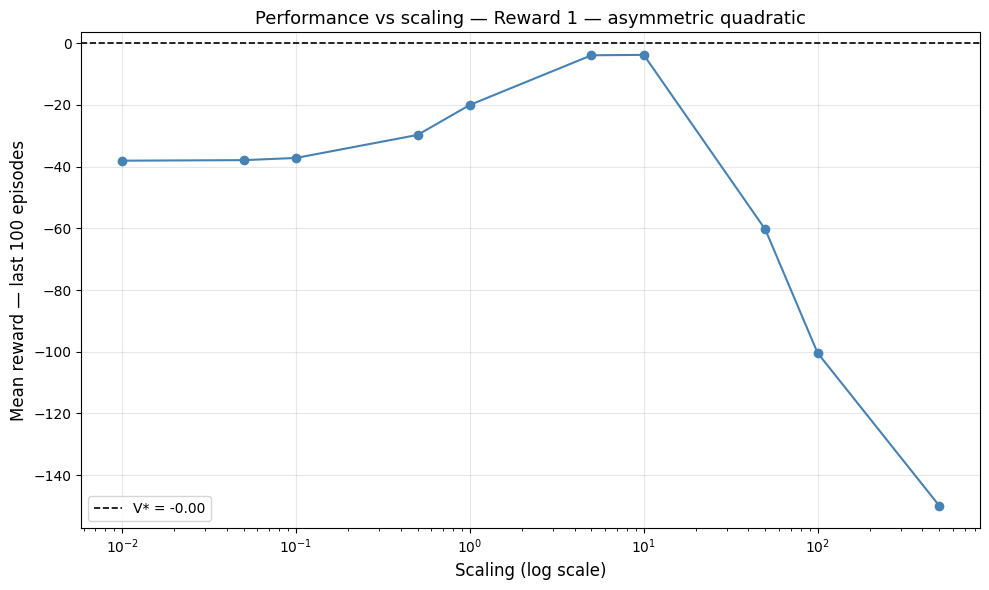

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(summary_df_r1['scaling'], summary_df_r1['late_mean_reward'], marker='o', color='steelblue', lw=1.5)
ax.axhline(V_STAR_R1, color='black', ls='--', lw=1.2, label=f'V* = {V_STAR_R1:.2f}')
ax.set_xscale('log')
ax.set_xlabel('Scaling (log scale)', fontsize=12)
ax.set_ylabel('Mean reward — last 100 episodes', fontsize=12)
ax.set_title('Performance vs scaling — Reward 1 — asymmetric quadratic', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


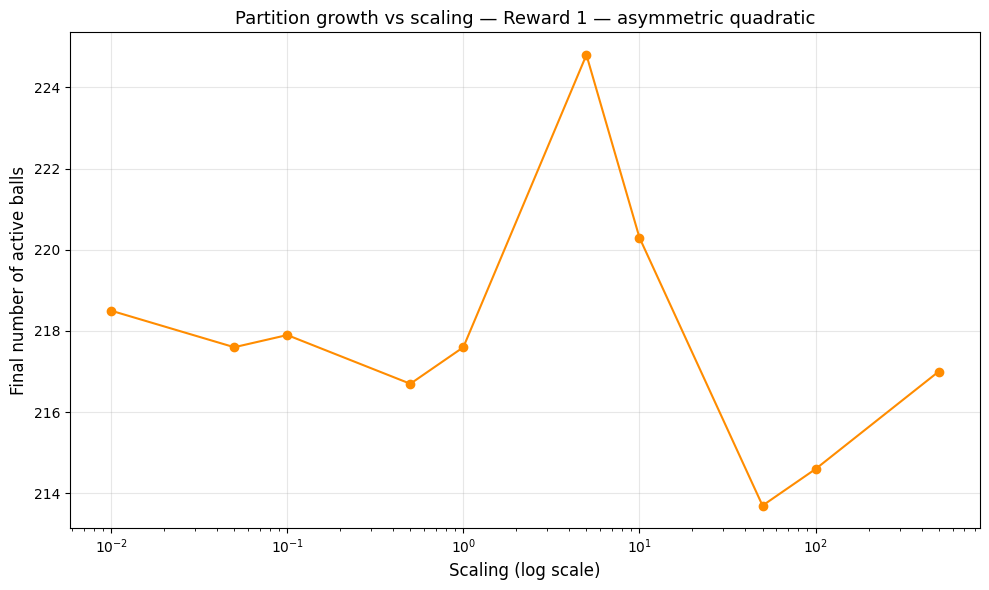

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(summary_df_r1['scaling'], summary_df_r1['final_arms'], marker='o', color='darkorange', lw=1.5)
ax.set_xscale('log')
ax.set_xlabel('Scaling (log scale)', fontsize=12)
ax.set_ylabel('Final number of active balls', fontsize=12)
ax.set_title('Partition growth vs scaling — Reward 1 — asymmetric quadratic', fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


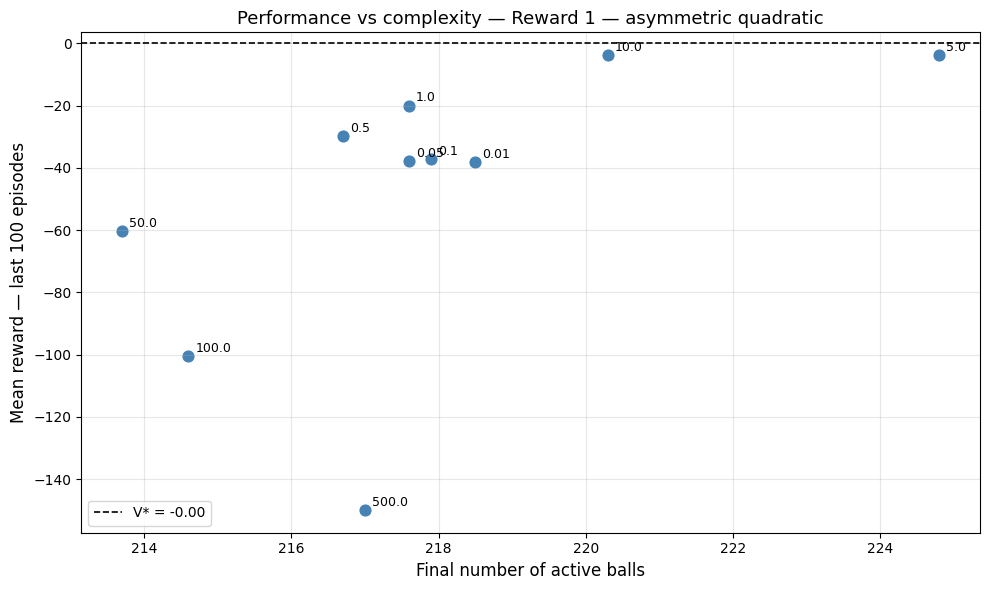

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(summary_df_r1['final_arms'], summary_df_r1['late_mean_reward'], color='steelblue', s=60)
for _, row in summary_df_r1.iterrows():
    ax.annotate(str(row['scaling']), (row['final_arms'], row['late_mean_reward']),
                textcoords='offset points', xytext=(5, 3), fontsize=9)
ax.axhline(V_STAR_R1, color='black', ls='--', lw=1.2, label=f'V* = {V_STAR_R1:.2f}')
ax.set_xlabel('Final number of active balls', fontsize=12)
ax.set_ylabel('Mean reward — last 100 episodes', fontsize=12)
ax.set_title('Performance vs complexity — Reward 1 — asymmetric quadratic', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [9]:
chosen_scalings_r1 = [0.1, 5, 100]

configs = [
    c.ExpConfig(
        starting_state=4.0, action_lo=-5.0, action_hi=5.0,
        initial_q=100.0, rho=10.0,
        reward_step_fn=c.reward_quadratic_asymmetric,
        label=f'scaling={s}', scaling=s, alpha=0.5, nEps=2000, n_seeds=10,
    )
    for s in chosen_scalings_r1
]
results_chosen_r1 = c.run_experiment(configs, n_jobs=-1)



--- Running: scaling=0.1 ---
    Done. Final mean VPI: -35.311

--- Running: scaling=5 ---
    Done. Final mean VPI: -3.371

--- Running: scaling=100 ---
    Done. Final mean VPI: -100.293


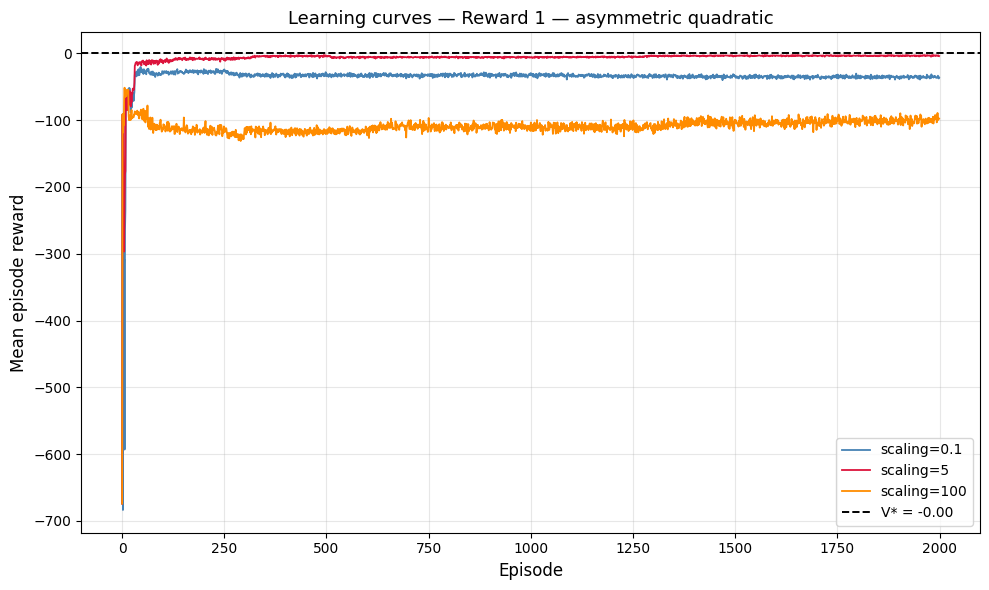

In [10]:
COLOURS = {0.1: 'steelblue', 5: 'crimson', 100: 'darkorange'}

fig, ax = plt.subplots(figsize=(10, 6))
for s in chosen_scalings_r1:
    ax.plot(results_chosen_r1[f'scaling={s}']['vpi'], label=f'scaling={s}', color=COLOURS[s], lw=1.3)
ax.axhline(V_STAR_R1, color='black', ls='--', lw=1.4, label=f'V* = {V_STAR_R1:.2f}')
ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel('Mean episode reward', fontsize=12)
ax.set_title('Learning curves — Reward 1 — asymmetric quadratic', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


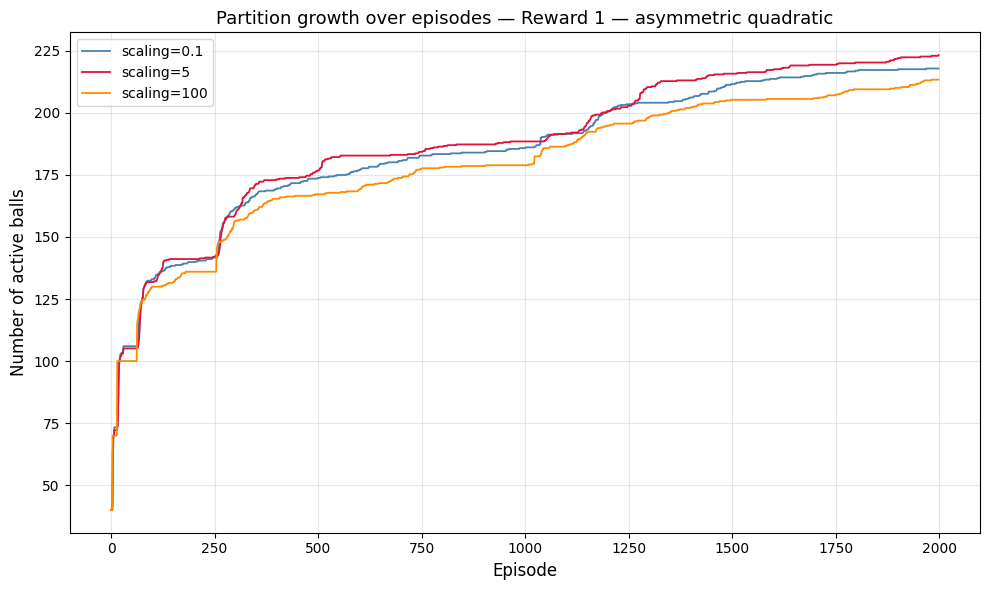

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
for s in chosen_scalings_r1:
    ax.plot(results_chosen_r1[f'scaling={s}']['arms'], label=f'scaling={s}', color=COLOURS[s], lw=1.3)
ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel('Number of active balls', fontsize=12)
ax.set_title('Partition growth over episodes — Reward 1 — asymmetric quadratic', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


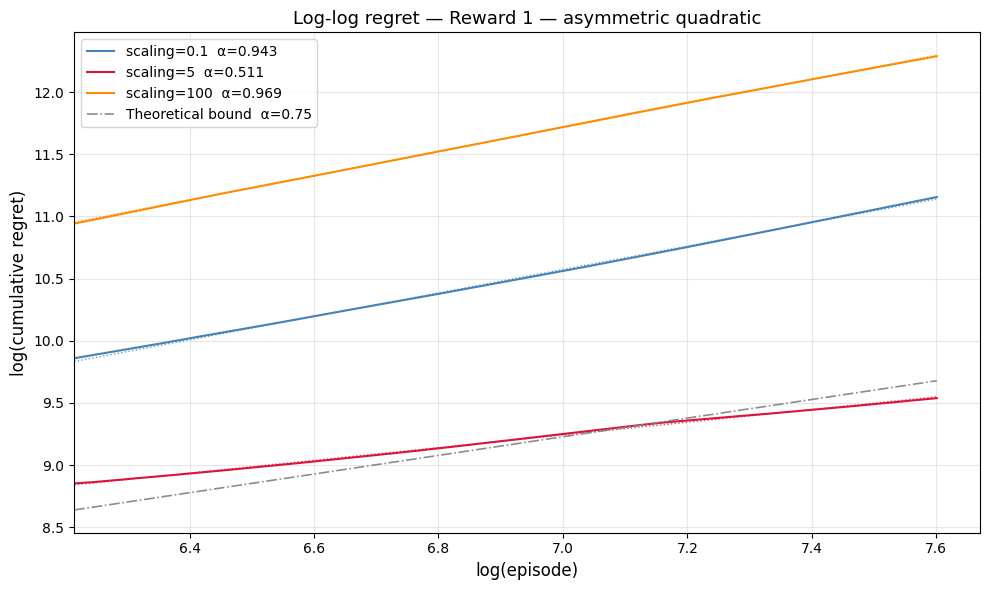

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

for s in chosen_scalings_r1:
    vpi     = results_chosen_r1[f'scaling={s}']['vpi']
    eps     = np.arange(1, len(vpi) + 1)
    cum_reg = np.cumsum(np.maximum(V_STAR_R1 - vpi, 0.0))
    mask    = (eps >= 500) & (cum_reg > 0)
    lx, ly  = np.log(eps[mask]), np.log(cum_reg[mask])
    slope, intercept, _, _, _ = stats.linregress(lx, ly)
    ax.plot(lx, ly, lw=1.5, color=COLOURS[s], label=f'scaling={s}  α={slope:.3f}')
    ax.plot(lx, slope*lx + intercept, lw=1.0, color=COLOURS[s], ls=':', alpha=0.8)

# Theoretical worst-case bound α=0.75 anchored through midpoint of best curve
_best_vpi = results_chosen_r1['scaling=5']['vpi']
_eps      = np.arange(1, len(_best_vpi) + 1)
_cum      = np.cumsum(np.maximum(V_STAR_R1 - _best_vpi, 0.0))
_mask     = (_eps >= 500) & (_cum > 0)
_mid      = len(_eps[_mask]) // 2
_th_ic    = np.log(max(_cum[_mask][_mid], 1e-8)) - 0.75 * np.log(_eps[_mask][_mid])
_lx_th    = np.array([np.log(500), np.log(len(_best_vpi))])
ax.plot(_lx_th, 0.75*_lx_th + _th_ic, lw=1.2, color='gray', ls='-.', alpha=0.9,
        label='Theoretical bound  α=0.75')

ax.set_xlim(left=np.log(500))
ax.set_xlabel('log(episode)', fontsize=12)
ax.set_ylabel('log(cumulative regret)', fontsize=12)
ax.set_title('Log-log regret — Reward 1 — asymmetric quadratic', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


 scaling  alpha  r_squared
    0.01 0.9453     0.9993
    0.05 0.9492     0.9992
    0.10 0.9496     0.9992
    0.50 0.9264     0.9992
    1.00 0.8526     0.9987
    5.00 0.5499     0.9982
   10.00 0.5789     0.9961
   50.00 0.8679     1.0000
  100.00 0.9768     0.9999
  500.00 1.0778     1.0000


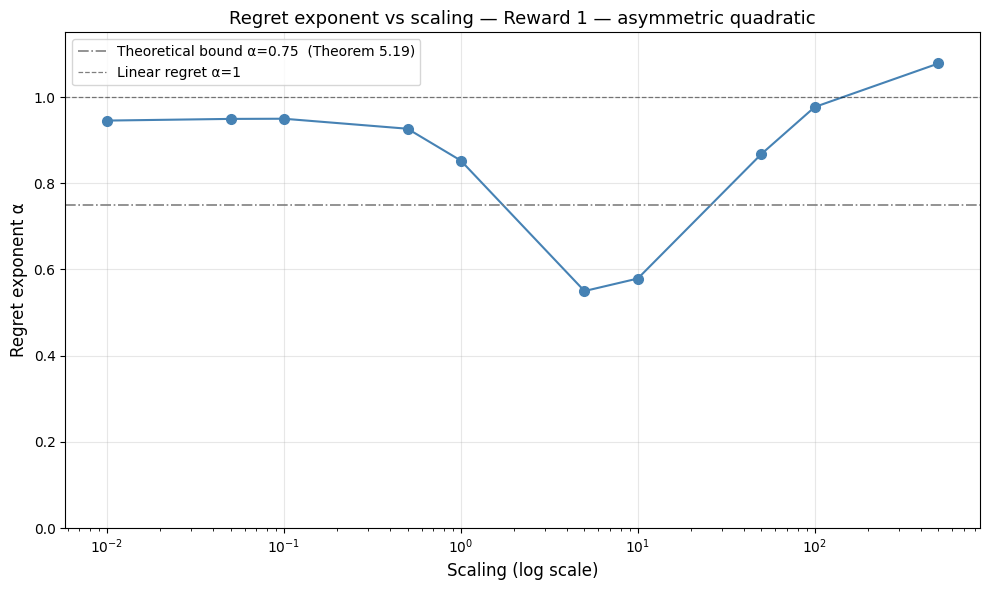

In [13]:
slopes_r1, _ = compute_regret_slopes(results_sweep_r1, scalings_r1, V_STAR_R1)
print(slopes_r1.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(slopes_r1['scaling'], slopes_r1['alpha'], marker='o', color='steelblue', lw=1.5, ms=7)
ax.axhline(0.75, color='gray',  ls='-.', lw=1.2, label='Theoretical bound α=0.75  (Theorem 5.19)')
ax.axhline(1.0,  color='black', ls='--', lw=0.9, alpha=0.5, label='Linear regret α=1')
ax.set_xscale('log')
ax.set_ylim(0, 1.15)
ax.set_xlabel('Scaling (log scale)', fontsize=12)
ax.set_ylabel('Regret exponent α', fontsize=12)
ax.set_title('Regret exponent vs scaling — Reward 1 — asymmetric quadratic', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Reward 2 — shifted quadratic

In [14]:
importlib.reload(c)

cfg_r2 = c.ExpConfig(
    starting_state=4.0,
    action_lo=-5.0,
    action_hi=5.0,
    rho=10.0,
    reward_step_fn=c.reward_quadratic_shifted,
)
solver_r2 = c.BellmanSolverScalar(cfg_r2, n_state=201, n_action=201, n_quad=41)
solver_r2.solve()
V_STAR_R2 = solver_r2.get_value(cfg_r2.starting_state)
print(f'V*(x0) = {V_STAR_R2:.4f}  (expected ≈ 100.0)')


V*(x0) = 100.0014  (expected ≈ 100.0)


In [15]:
scalings_r2 = [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100, 500]

configs = [
    c.ExpConfig(
        starting_state=4.0, action_lo=-5.0, action_hi=5.0,
        initial_q=100.0, rho=10.0,
        reward_step_fn=c.reward_quadratic_shifted,
        label=f'scaling={s}', scaling=s, alpha=0.5, nEps=2000, n_seeds=10,
    )
    for s in scalings_r2
]
results_sweep_r2 = c.run_experiment(configs, n_jobs=-1)



--- Running: scaling=0.01 ---
    Done. Final mean VPI: 92.269

--- Running: scaling=0.05 ---
    Done. Final mean VPI: 93.008

--- Running: scaling=0.1 ---
    Done. Final mean VPI: 93.362

--- Running: scaling=0.5 ---
    Done. Final mean VPI: 95.250

--- Running: scaling=1 ---
    Done. Final mean VPI: 97.262

--- Running: scaling=5 ---
    Done. Final mean VPI: 91.180

--- Running: scaling=10 ---
    Done. Final mean VPI: 83.191

--- Running: scaling=50 ---
    Done. Final mean VPI: 57.960

--- Running: scaling=100 ---
    Done. Final mean VPI: 45.203

--- Running: scaling=500 ---
    Done. Final mean VPI: 36.386


In [16]:
summary_r2 = []
for s in scalings_r2:
    label = f'scaling={s}'
    vpi  = results_sweep_r2[label]['vpi']
    arms = results_sweep_r2[label]['arms']
    summary_r2.append({
        'scaling': s,
        'final_cum_reward':  np.sum(vpi),
        'late_mean_reward':  np.mean(vpi[-100:]),
        'final_arms':        arms[-1],
        'mean_arms_last100': np.mean(arms[-100:]),
    })
summary_df_r2 = pd.DataFrame(summary_r2)
summary_df_r2


,scaling,final_cum_reward,late_mean_reward,final_arms,mean_arms_last100
0,0.01,185261.102378,92.269279,219.4,217.600
1,0.05,186518.078331,93.008236,219.4,217.807
2,0.10,187157.003126,93.362077,219.1,217.858
3,0.50,190348.025993,95.250140,221.2,219.031
4,1.00,193741.269087,97.261927,219.4,216.868
5,5.00,180878.326602,91.180065,208.3,208.039
6,10.00,163901.130754,83.191345,210.1,208.780
7,50.00,113952.188522,57.959894,211.9,211.537
8,100.00,91216.003975,45.203417,214.6,214.600
9,500.00,79705.822933,36.385752,217.0,217.000


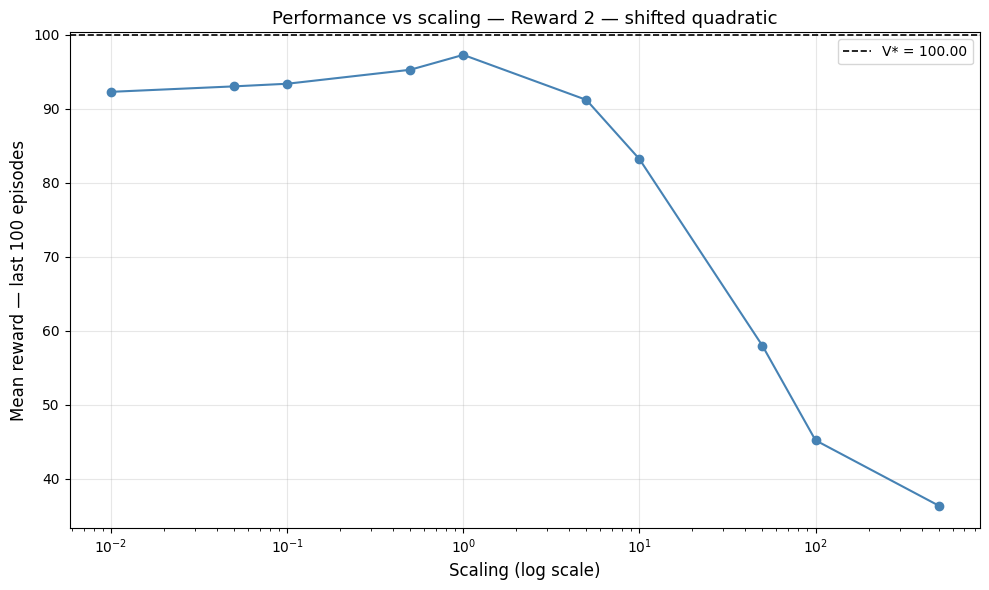

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(summary_df_r2['scaling'], summary_df_r2['late_mean_reward'], marker='o', color='steelblue', lw=1.5)
ax.axhline(V_STAR_R2, color='black', ls='--', lw=1.2, label=f'V* = {V_STAR_R2:.2f}')
ax.set_xscale('log')
ax.set_xlabel('Scaling (log scale)', fontsize=12)
ax.set_ylabel('Mean reward — last 100 episodes', fontsize=12)
ax.set_title('Performance vs scaling — Reward 2 — shifted quadratic', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


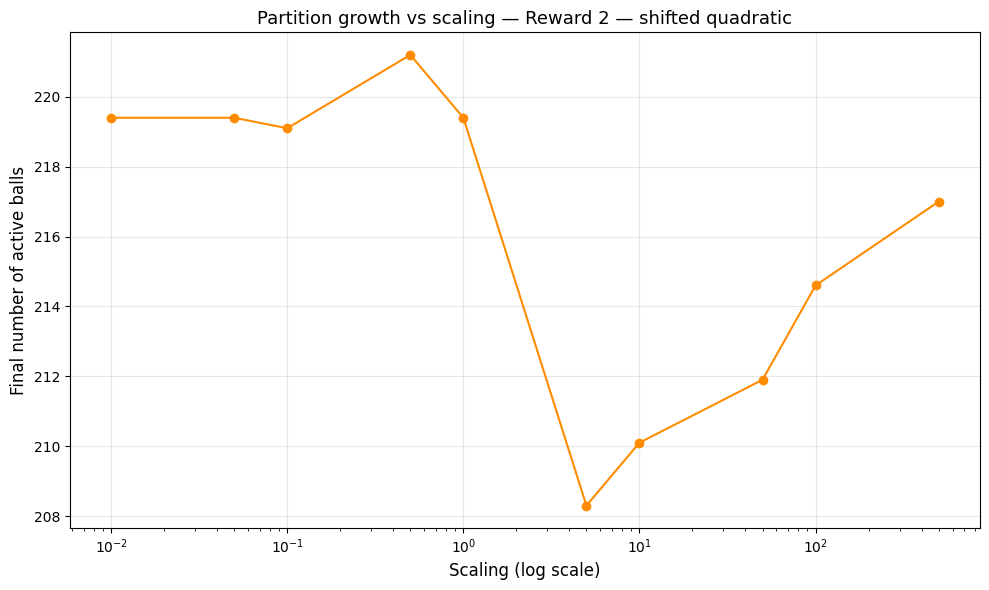

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(summary_df_r2['scaling'], summary_df_r2['final_arms'], marker='o', color='darkorange', lw=1.5)
ax.set_xscale('log')
ax.set_xlabel('Scaling (log scale)', fontsize=12)
ax.set_ylabel('Final number of active balls', fontsize=12)
ax.set_title('Partition growth vs scaling — Reward 2 — shifted quadratic', fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


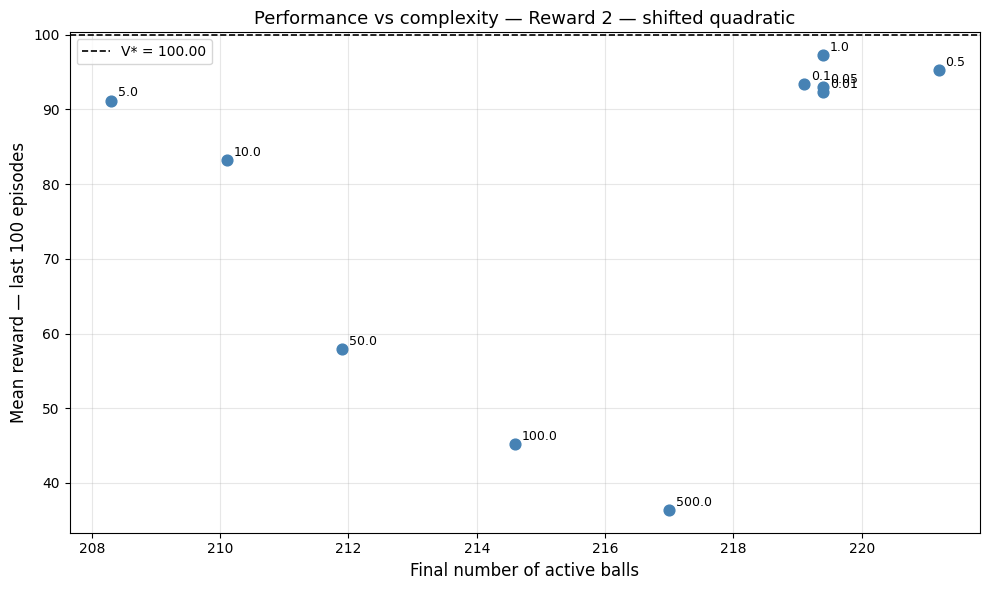

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(summary_df_r2['final_arms'], summary_df_r2['late_mean_reward'], color='steelblue', s=60)
for _, row in summary_df_r2.iterrows():
    ax.annotate(str(row['scaling']), (row['final_arms'], row['late_mean_reward']),
                textcoords='offset points', xytext=(5, 3), fontsize=9)
ax.axhline(V_STAR_R2, color='black', ls='--', lw=1.2, label=f'V* = {V_STAR_R2:.2f}')
ax.set_xlabel('Final number of active balls', fontsize=12)
ax.set_ylabel('Mean reward — last 100 episodes', fontsize=12)
ax.set_title('Performance vs complexity — Reward 2 — shifted quadratic', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [20]:
chosen_scalings_r2 = [0.1, 5, 100]

configs = [
    c.ExpConfig(
        starting_state=4.0, action_lo=-5.0, action_hi=5.0,
        initial_q=100.0, rho=10.0,
        reward_step_fn=c.reward_quadratic_shifted,
        label=f'scaling={s}', scaling=s, alpha=0.5, nEps=2000, n_seeds=10,
    )
    for s in chosen_scalings_r2
]
results_chosen_r2 = c.run_experiment(configs, n_jobs=-1)



--- Running: scaling=0.1 ---
    Done. Final mean VPI: 93.592

--- Running: scaling=5 ---
    Done. Final mean VPI: 91.371

--- Running: scaling=100 ---
    Done. Final mean VPI: 45.378


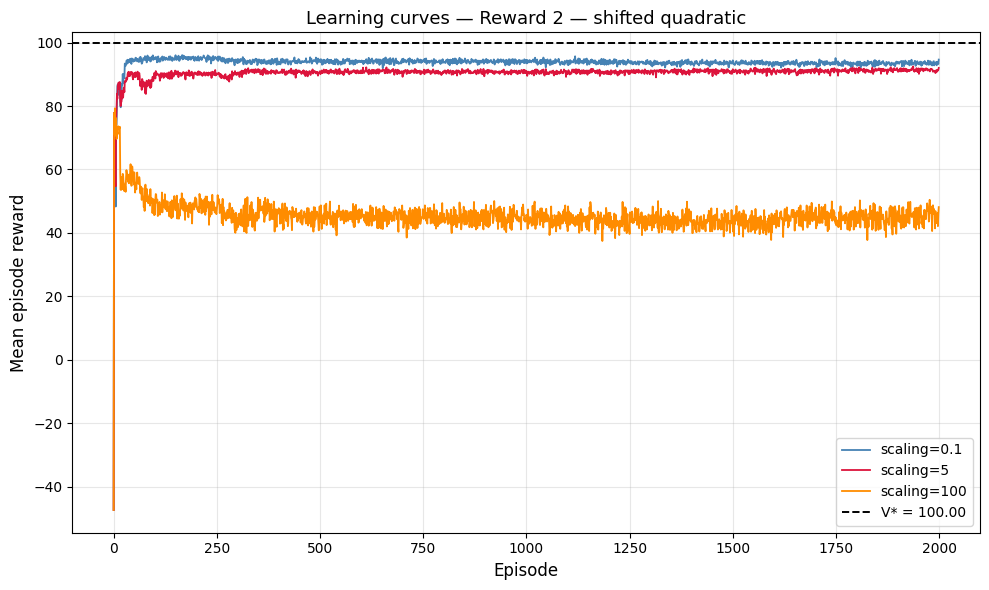

In [21]:
COLOURS = {0.1: 'steelblue', 5: 'crimson', 100: 'darkorange'}

fig, ax = plt.subplots(figsize=(10, 6))
for s in chosen_scalings_r2:
    ax.plot(results_chosen_r2[f'scaling={s}']['vpi'], label=f'scaling={s}', color=COLOURS[s], lw=1.3)
ax.axhline(V_STAR_R2, color='black', ls='--', lw=1.4, label=f'V* = {V_STAR_R2:.2f}')
ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel('Mean episode reward', fontsize=12)
ax.set_title('Learning curves — Reward 2 — shifted quadratic', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


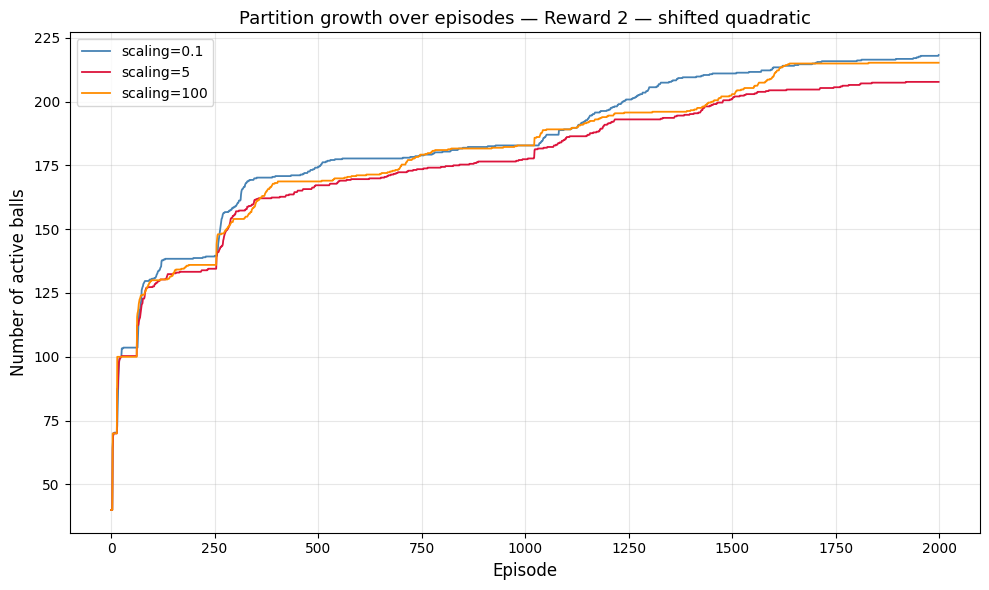

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))
for s in chosen_scalings_r2:
    ax.plot(results_chosen_r2[f'scaling={s}']['arms'], label=f'scaling={s}', color=COLOURS[s], lw=1.3)
ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel('Number of active balls', fontsize=12)
ax.set_title('Partition growth over episodes — Reward 2 — shifted quadratic', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


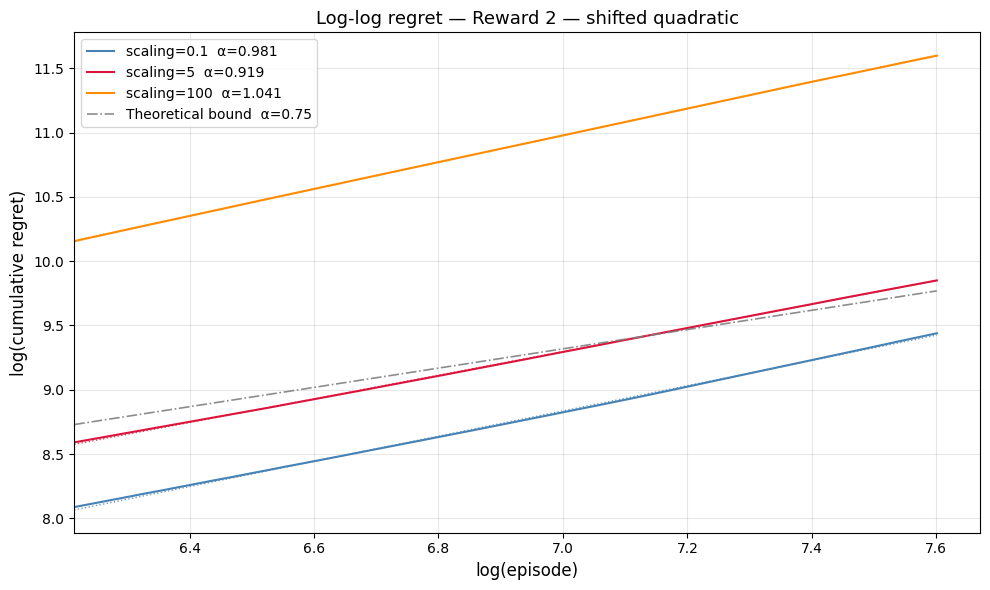

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))

for s in chosen_scalings_r2:
    vpi     = results_chosen_r2[f'scaling={s}']['vpi']
    eps     = np.arange(1, len(vpi) + 1)
    cum_reg = np.cumsum(np.maximum(V_STAR_R2 - vpi, 0.0))
    mask    = (eps >= 500) & (cum_reg > 0)
    lx, ly  = np.log(eps[mask]), np.log(cum_reg[mask])
    slope, intercept, _, _, _ = stats.linregress(lx, ly)
    ax.plot(lx, ly, lw=1.5, color=COLOURS[s], label=f'scaling={s}  α={slope:.3f}')
    ax.plot(lx, slope*lx + intercept, lw=1.0, color=COLOURS[s], ls=':', alpha=0.8)

# Theoretical worst-case bound α=0.75 anchored through midpoint of best curve
_best_vpi = results_chosen_r2['scaling=5']['vpi']
_eps      = np.arange(1, len(_best_vpi) + 1)
_cum      = np.cumsum(np.maximum(V_STAR_R2 - _best_vpi, 0.0))
_mask     = (_eps >= 500) & (_cum > 0)
_mid      = len(_eps[_mask]) // 2
_th_ic    = np.log(max(_cum[_mask][_mid], 1e-8)) - 0.75 * np.log(_eps[_mask][_mid])
_lx_th    = np.array([np.log(500), np.log(len(_best_vpi))])
ax.plot(_lx_th, 0.75*_lx_th + _th_ic, lw=1.2, color='gray', ls='-.', alpha=0.9,
        label='Theoretical bound  α=0.75')

ax.set_xlim(left=np.log(500))
ax.set_xlabel('log(episode)', fontsize=12)
ax.set_ylabel('log(cumulative regret)', fontsize=12)
ax.set_title('Log-log regret — Reward 2 — shifted quadratic', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


 scaling  alpha  r_squared
    0.01 0.9984     0.9996
    0.05 0.9889     0.9996
    0.10 0.9904     0.9995
    0.50 0.9189     0.9996
    1.00 0.7713     0.9988
    5.00 0.9187     0.9998
   10.00 0.9245     1.0000
   50.00 0.9897     1.0000
  100.00 1.0427     1.0000
  500.00 1.0646     1.0000


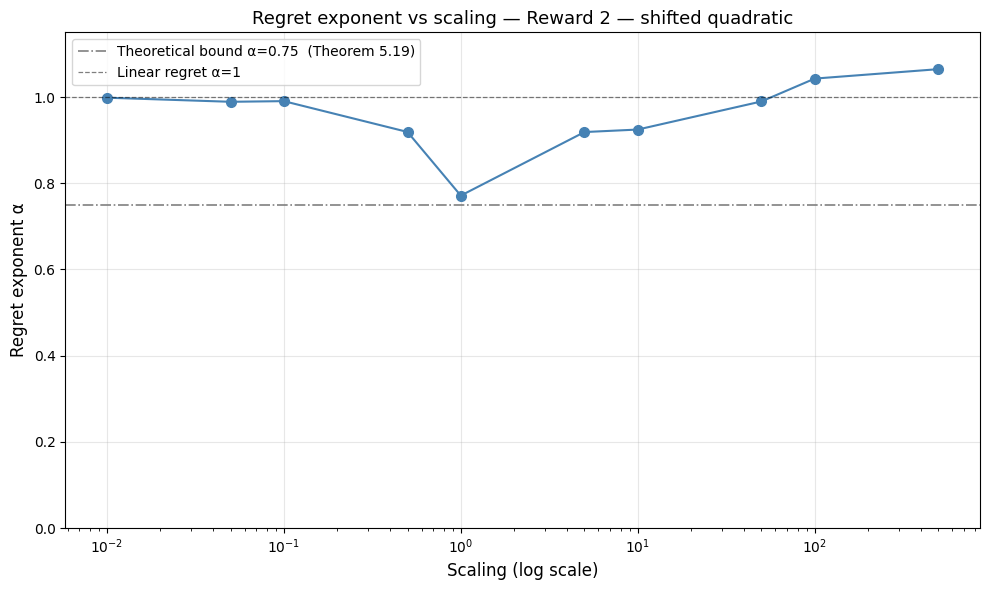

In [24]:
slopes_r2, _ = compute_regret_slopes(results_sweep_r2, scalings_r2, V_STAR_R2)
print(slopes_r2.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(slopes_r2['scaling'], slopes_r2['alpha'], marker='o', color='steelblue', lw=1.5, ms=7)
ax.axhline(0.75, color='gray',  ls='-.', lw=1.2, label='Theoretical bound α=0.75  (Theorem 5.19)')
ax.axhline(1.0,  color='black', ls='--', lw=0.9, alpha=0.5, label='Linear regret α=1')
ax.set_xscale('log')
ax.set_ylim(0, 1.15)
ax.set_xlabel('Scaling (log scale)', fontsize=12)
ax.set_ylabel('Regret exponent α', fontsize=12)
ax.set_title('Regret exponent vs scaling — Reward 2 — shifted quadratic', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Reward 3 — quartic

In [25]:
importlib.reload(c)

cfg_r3 = c.ExpConfig(
    starting_state=4.0,
    action_lo=-5.0,
    action_hi=5.0,
    rho=10.0,
    reward_step_fn=c.reward_quartic,
)
solver_r3 = c.BellmanSolverScalar(cfg_r3, n_state=201, n_action=201, n_quad=41)
solver_r3.solve()
V_STAR_R3 = solver_r3.get_value(cfg_r3.starting_state)
print(f'V*(x0) = {V_STAR_R3:.4f}  (expected ≈ 0.0)')


V*(x0) = 0.0226  (expected ≈ 0.0)


In [26]:
scalings_r3 = [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100, 500]

configs = [
    c.ExpConfig(
        starting_state=4.0, action_lo=-5.0, action_hi=5.0,
        initial_q=100.0, rho=10.0,
        reward_step_fn=c.reward_quartic,
        label=f'scaling={s}', scaling=s, alpha=0.5, nEps=2000, n_seeds=10,
    )
    for s in scalings_r3
]
results_sweep_r3 = c.run_experiment(configs, n_jobs=-1)



--- Running: scaling=0.01 ---
    Done. Final mean VPI: -43.259

--- Running: scaling=0.05 ---
    Done. Final mean VPI: -42.089

--- Running: scaling=0.1 ---
    Done. Final mean VPI: -42.173

--- Running: scaling=0.5 ---
    Done. Final mean VPI: -35.061

--- Running: scaling=1 ---
    Done. Final mean VPI: -29.288

--- Running: scaling=5 ---
    Done. Final mean VPI: -9.172

--- Running: scaling=10 ---
    Done. Final mean VPI: -5.003

--- Running: scaling=50 ---
    Done. Final mean VPI: -31.260

--- Running: scaling=100 ---
    Done. Final mean VPI: -67.050

--- Running: scaling=500 ---
    Done. Final mean VPI: -214.468


In [27]:
summary_r3 = []
for s in scalings_r3:
    label = f'scaling={s}'
    vpi  = results_sweep_r3[label]['vpi']
    arms = results_sweep_r3[label]['arms']
    summary_r3.append({
        'scaling': s,
        'final_cum_reward':  np.sum(vpi),
        'late_mean_reward':  np.mean(vpi[-100:]),
        'final_arms':        arms[-1],
        'mean_arms_last100': np.mean(arms[-100:]),
    })
summary_df_r3 = pd.DataFrame(summary_r3)
summary_df_r3


,scaling,final_cum_reward,late_mean_reward,final_arms,mean_arms_last100
0,0.01,-108577.389904,-43.259112,217.6,217.600
1,0.05,-108644.742665,-42.089414,218.2,217.996
2,0.10,-107654.167722,-42.173120,218.8,218.668
3,0.50,-94086.624429,-35.061266,218.8,218.518
4,1.00,-82163.007224,-29.288090,218.5,218.020
5,5.00,-36722.135984,-9.171630,219.1,217.552
6,10.00,-28099.575613,-5.002645,215.2,213.403
7,50.00,-89053.239319,-31.259674,209.8,209.800
8,100.00,-178865.296307,-67.049688,217.0,216.655
9,500.00,-408185.414836,-214.467960,217.0,217.000


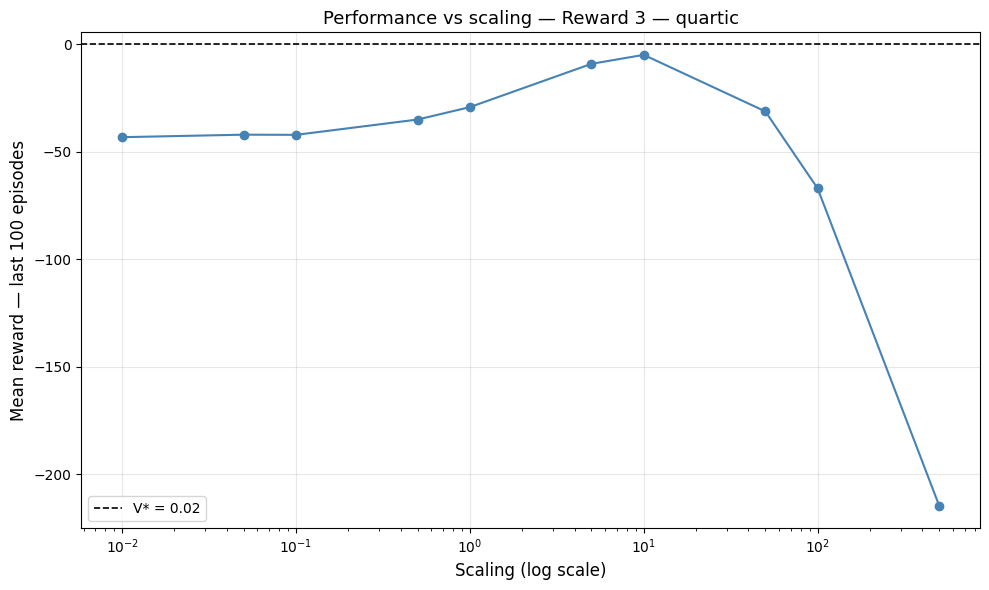

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(summary_df_r3['scaling'], summary_df_r3['late_mean_reward'], marker='o', color='steelblue', lw=1.5)
ax.axhline(V_STAR_R3, color='black', ls='--', lw=1.2, label=f'V* = {V_STAR_R3:.2f}')
ax.set_xscale('log')
ax.set_xlabel('Scaling (log scale)', fontsize=12)
ax.set_ylabel('Mean reward — last 100 episodes', fontsize=12)
ax.set_title('Performance vs scaling — Reward 3 — quartic', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


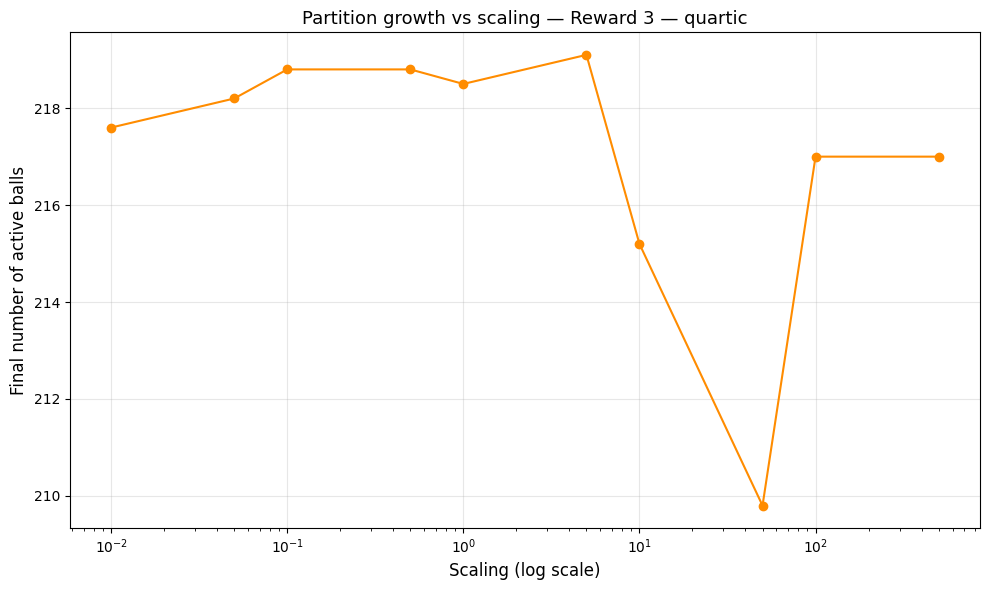

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(summary_df_r3['scaling'], summary_df_r3['final_arms'], marker='o', color='darkorange', lw=1.5)
ax.set_xscale('log')
ax.set_xlabel('Scaling (log scale)', fontsize=12)
ax.set_ylabel('Final number of active balls', fontsize=12)
ax.set_title('Partition growth vs scaling — Reward 3 — quartic', fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


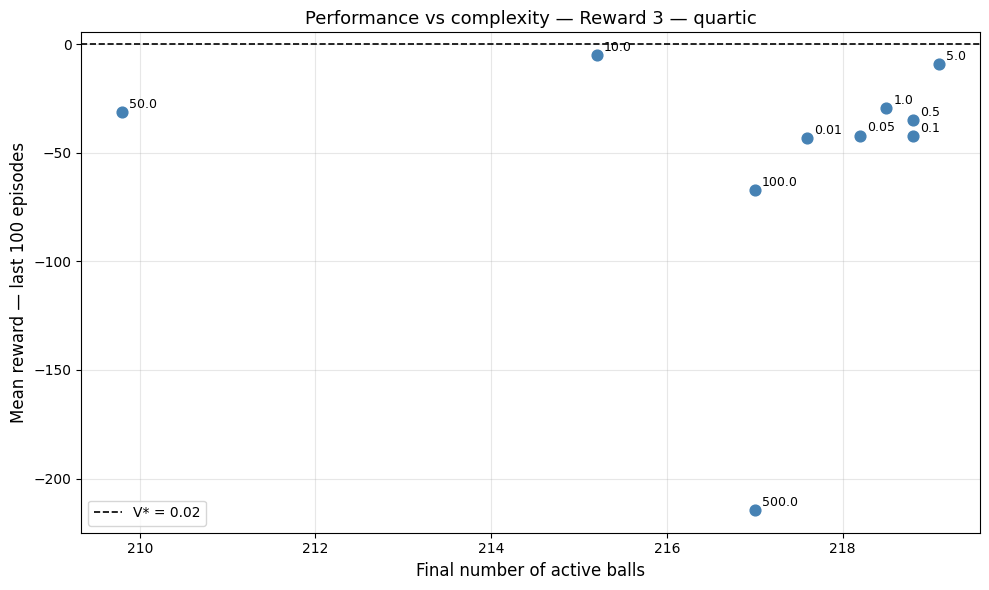

In [30]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(summary_df_r3['final_arms'], summary_df_r3['late_mean_reward'], color='steelblue', s=60)
for _, row in summary_df_r3.iterrows():
    ax.annotate(str(row['scaling']), (row['final_arms'], row['late_mean_reward']),
                textcoords='offset points', xytext=(5, 3), fontsize=9)
ax.axhline(V_STAR_R3, color='black', ls='--', lw=1.2, label=f'V* = {V_STAR_R3:.2f}')
ax.set_xlabel('Final number of active balls', fontsize=12)
ax.set_ylabel('Mean reward — last 100 episodes', fontsize=12)
ax.set_title('Performance vs complexity — Reward 3 — quartic', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [31]:
chosen_scalings_r3 = [0.1, 5, 100]

configs = [
    c.ExpConfig(
        starting_state=4.0, action_lo=-5.0, action_hi=5.0,
        initial_q=100.0, rho=10.0,
        reward_step_fn=c.reward_quartic,
        label=f'scaling={s}', scaling=s, alpha=0.5, nEps=2000, n_seeds=10,
    )
    for s in chosen_scalings_r3
]
results_chosen_r3 = c.run_experiment(configs, n_jobs=-1)



--- Running: scaling=0.1 ---
    Done. Final mean VPI: -42.756

--- Running: scaling=5 ---
    Done. Final mean VPI: -10.777

--- Running: scaling=100 ---
    Done. Final mean VPI: -67.061


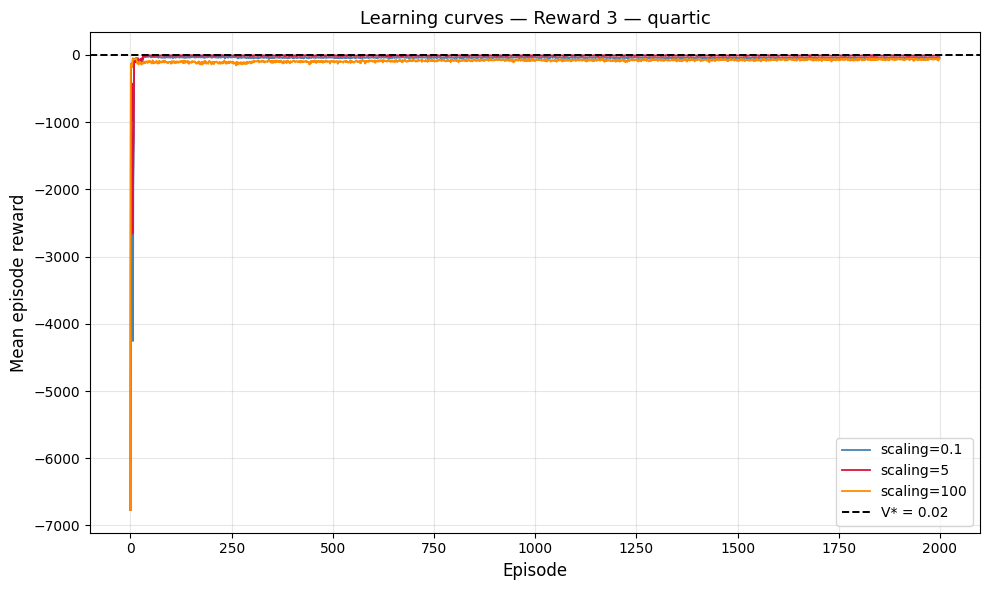

In [32]:
COLOURS = {0.1: 'steelblue', 5: 'crimson', 100: 'darkorange'}

fig, ax = plt.subplots(figsize=(10, 6))
for s in chosen_scalings_r3:
    ax.plot(results_chosen_r3[f'scaling={s}']['vpi'], label=f'scaling={s}', color=COLOURS[s], lw=1.3)
ax.axhline(V_STAR_R3, color='black', ls='--', lw=1.4, label=f'V* = {V_STAR_R3:.2f}')
ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel('Mean episode reward', fontsize=12)
ax.set_title('Learning curves — Reward 3 — quartic', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


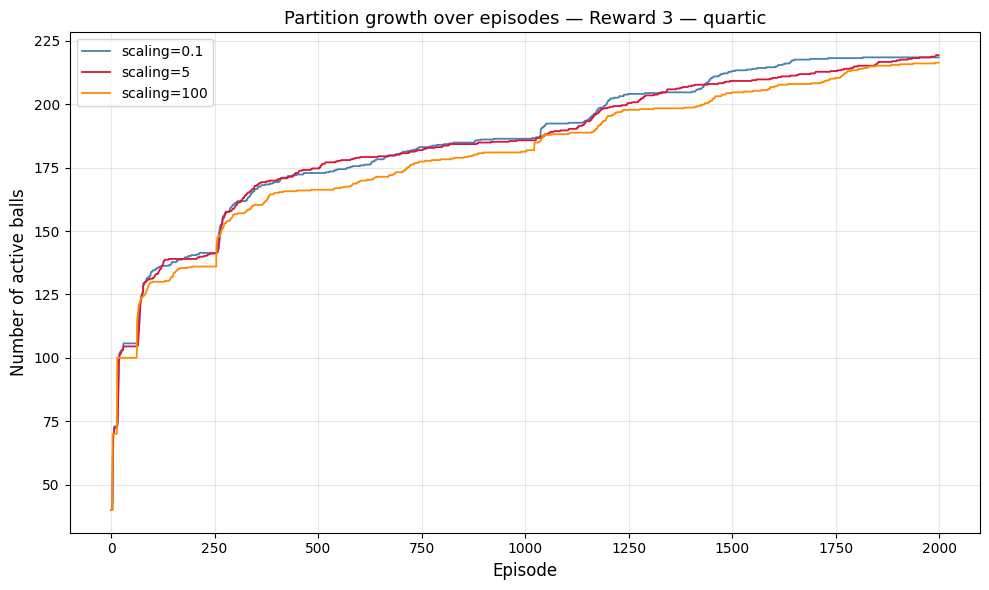

In [33]:
fig, ax = plt.subplots(figsize=(10, 6))
for s in chosen_scalings_r3:
    ax.plot(results_chosen_r3[f'scaling={s}']['arms'], label=f'scaling={s}', color=COLOURS[s], lw=1.3)
ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel('Number of active balls', fontsize=12)
ax.set_title('Partition growth over episodes — Reward 3 — quartic', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


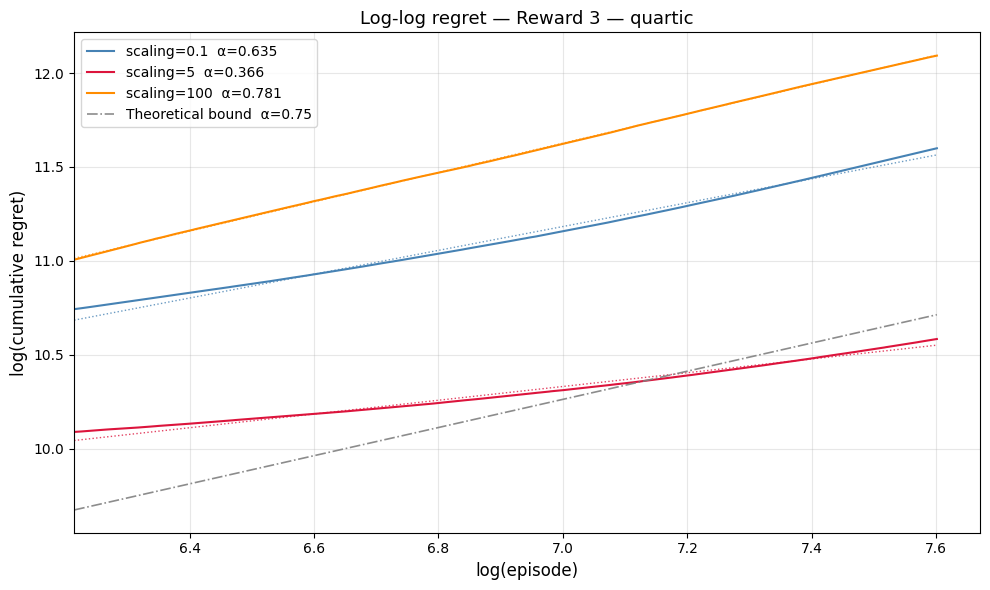

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))

for s in chosen_scalings_r3:
    vpi     = results_chosen_r3[f'scaling={s}']['vpi']
    eps     = np.arange(1, len(vpi) + 1)
    cum_reg = np.cumsum(np.maximum(V_STAR_R3 - vpi, 0.0))
    mask    = (eps >= 500) & (cum_reg > 0)
    lx, ly  = np.log(eps[mask]), np.log(cum_reg[mask])
    slope, intercept, _, _, _ = stats.linregress(lx, ly)
    ax.plot(lx, ly, lw=1.5, color=COLOURS[s], label=f'scaling={s}  α={slope:.3f}')
    ax.plot(lx, slope*lx + intercept, lw=1.0, color=COLOURS[s], ls=':', alpha=0.8)

# Theoretical worst-case bound α=0.75 anchored through midpoint of best curve
_best_vpi = results_chosen_r3['scaling=5']['vpi']
_eps      = np.arange(1, len(_best_vpi) + 1)
_cum      = np.cumsum(np.maximum(V_STAR_R3 - _best_vpi, 0.0))
_mask     = (_eps >= 500) & (_cum > 0)
_mid      = len(_eps[_mask]) // 2
_th_ic    = np.log(max(_cum[_mask][_mid], 1e-8)) - 0.75 * np.log(_eps[_mask][_mid])
_lx_th    = np.array([np.log(500), np.log(len(_best_vpi))])
ax.plot(_lx_th, 0.75*_lx_th + _th_ic, lw=1.2, color='gray', ls='-.', alpha=0.9,
        label='Theoretical bound  α=0.75')

ax.set_xlim(left=np.log(500))
ax.set_xlabel('log(episode)', fontsize=12)
ax.set_ylabel('log(cumulative regret)', fontsize=12)
ax.set_title('Log-log regret — Reward 3 — quartic', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


 scaling  alpha  r_squared
    0.01 0.6257     0.9928
    0.05 0.6282     0.9928
    0.10 0.6264     0.9920
    0.50 0.5763     0.9910
    1.00 0.5264     0.9895
    5.00 0.3344     0.9837
   10.00 0.2325     0.9844
   50.00 0.6409     0.9994
  100.00 0.7822     0.9999
  500.00 1.0605     0.9999


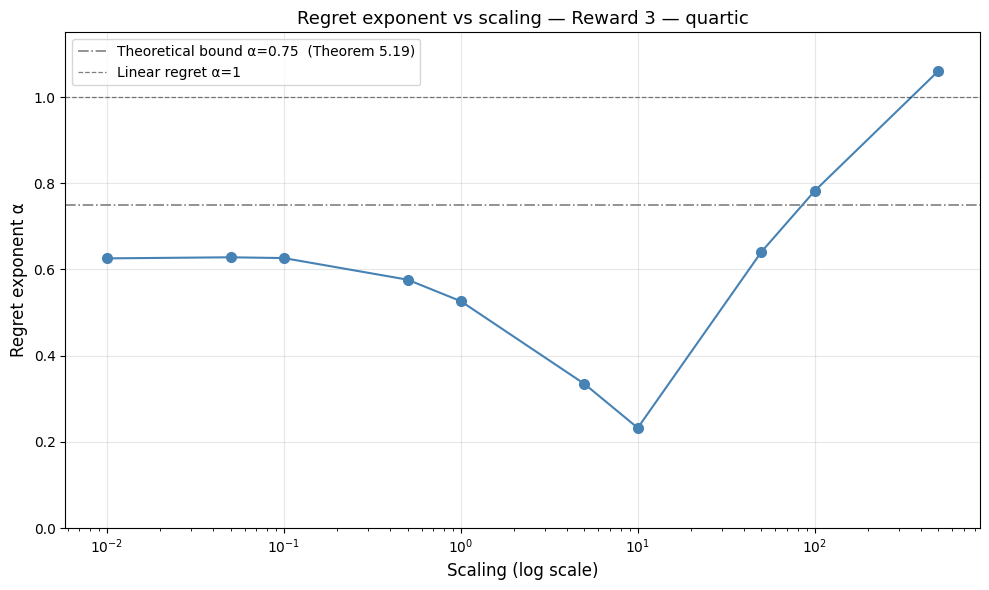

In [35]:
slopes_r3, _ = compute_regret_slopes(results_sweep_r3, scalings_r3, V_STAR_R3)
print(slopes_r3.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(slopes_r3['scaling'], slopes_r3['alpha'], marker='o', color='steelblue', lw=1.5, ms=7)
ax.axhline(0.75, color='gray',  ls='-.', lw=1.2, label='Theoretical bound α=0.75  (Theorem 5.19)')
ax.axhline(1.0,  color='black', ls='--', lw=0.9, alpha=0.5, label='Linear regret α=1')
ax.set_xscale('log')
ax.set_ylim(0, 1.15)
ax.set_xlabel('Scaling (log scale)', fontsize=12)
ax.set_ylabel('Regret exponent α', fontsize=12)
ax.set_title('Regret exponent vs scaling — Reward 3 — quartic', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Cross-reward comparison

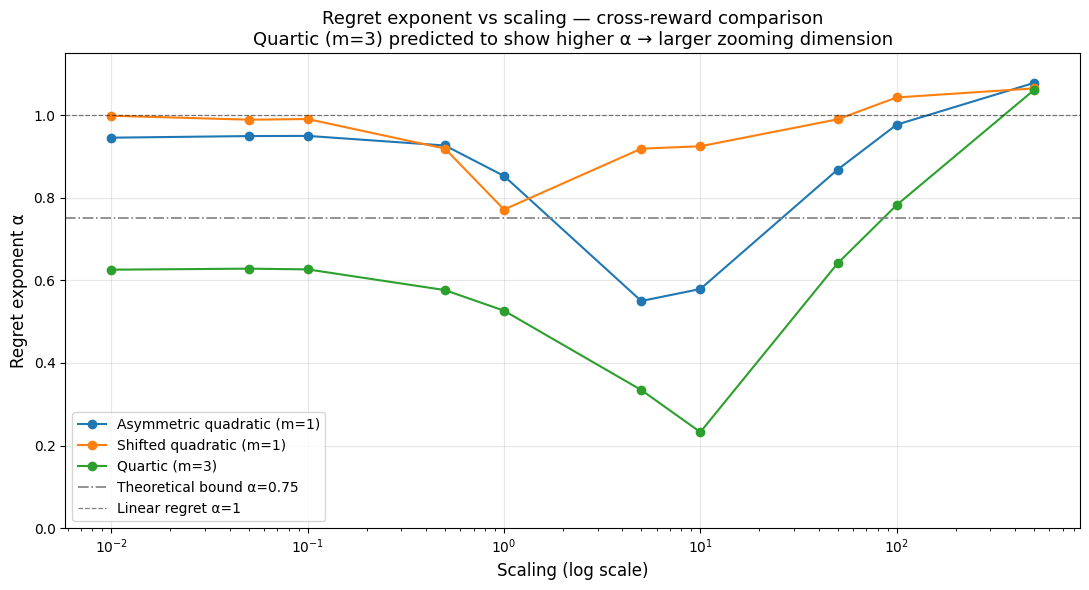

In [36]:
fig, ax = plt.subplots(figsize=(11, 6))

for slopes, label, colour in [
    (slopes_r1, 'Asymmetric quadratic (m=1)', 'steelblue'),
    (slopes_r2, 'Shifted quadratic (m=1)',    'crimson'),
    (slopes_r3, 'Quartic (m=3)',              'darkorange'),
]:
    ax.plot(slopes['scaling'], slopes['alpha'], marker='o', lw=1.5, label=label)

ax.axhline(0.75, color='gray',  ls='-.', lw=1.2, label='Theoretical bound α=0.75')
ax.axhline(1.0,  color='black', ls='--', lw=0.9, alpha=0.5, label='Linear regret α=1')
ax.set_xscale('log')
ax.set_ylim(0, 1.15)
ax.set_xlabel('Scaling (log scale)', fontsize=12)
ax.set_ylabel('Regret exponent α', fontsize=12)
ax.set_title('Regret exponent vs scaling — cross-reward comparison\n'
             'Quartic (m=3) predicted to show higher α → larger zooming dimension', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
